In [1]:
import glob
import json
import random
from copy import deepcopy as dc
from os.path import join as opj

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
from scipy.stats import spearmanr

from cloth_fmri.config.config import CONFIG
from cloth_fmri.utils.stats import (
    bootstrap_ci,
    bootstrap_cor,
    calc_p,
)
from cloth_fmri.utils.plot import plot_scene_bar_with_points, plot_bootstrap_violin
from cloth_fmri.utils.svm import (
    get_cnn_distance,
    get_woven_distance,
    get_videomae_distance,
    get_vivit_distance,
    get_vjepa2_distance
)


random.seed(9)

/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/nilearn/__init__.py:67: FutureWarning: Python 3.7 support is deprecated and will be removed in release 0.12 of Nilearn. Consider switching to Python 3.9 or 3.10.
  _python_deprecation_warnings()
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/outdated/utils.py:18: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs


# Fig. 3D. 
### Get model predicted distance between stiff and soft cloth across scenarios

In [2]:
###### Get model predicted distance between stiff and soft cloth across scenarios
woven_distance = get_woven_distance(verbose=False)
cnn_distance = get_cnn_distance(verbose=False)

woven_mean = [np.mean(woven_distance[i]) for i in woven_distance]
cnn_mean = [np.mean(cnn_distance[i]) for i in cnn_distance]

print("WOVEN predicted distance:", [f"{x:.3f}" for x in woven_mean])
print("CNN predicted distance:", [f"{x:.3f}" for x in cnn_mean])

r = spearmanr(woven_mean, cnn_mean)
print(f"@ correlation between two models: r = {r.correlation:.3f}, p = {r.pvalue:.3f}")

WOVEN predicted distance: ['1.814', '1.569', '1.775', '1.370']
CNN predicted distance: ['1.164', '0.710', '1.516', '1.296']
@ correlation between two models: r = 0.000, p = 1.000


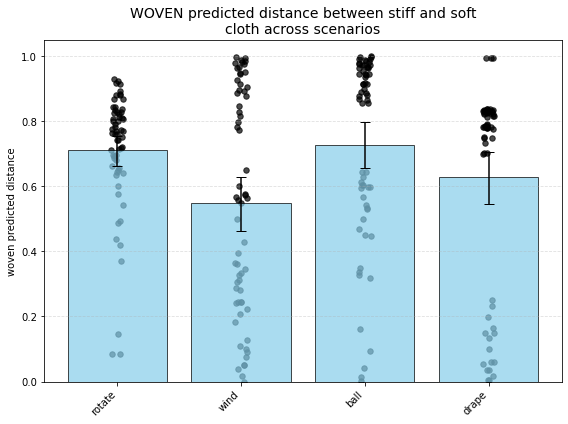

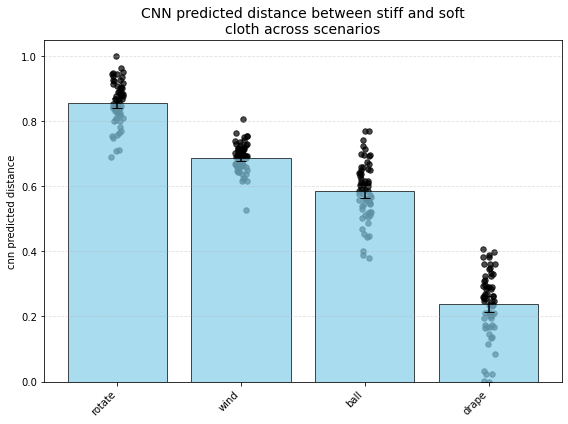

In [3]:
scene_order = ["rotate", "wind", "ball", "drape"]

for model in ["woven", "cnn"]:

    # ----------------------------------------------------
    # Load and prepare data
    # ----------------------------------------------------
    distance = eval(f"{model}_distance")
    scenes = scene_order

    data = np.stack([distance[scene][:62] for scene in scenes]).T
    normalized = (data - data.min()) / (data.max() - data.min())

    num_scenes = normalized.shape[1]

    # ----------------------------------------------------
    # Compute per-scene mean + bootstrap 95% CI
    # ----------------------------------------------------
    means = np.zeros(num_scenes)
    ci_low = np.zeros(num_scenes)
    ci_high = np.zeros(num_scenes)

    for i in range(num_scenes):
        scene_vals = normalized[:, i]
        means[i] = np.mean(scene_vals)

        lower, upper, _ = bootstrap_ci(scene_vals, nboot=5000)
        ci_low[i] = lower
        ci_high[i] = upper

    lower_err = means - ci_low
    upper_err = ci_high - means
    error_bars = np.vstack([lower_err, upper_err])

    # ----------------------------------------------------
    # Plot
    # ----------------------------------------------------
    fig, ax = plot_scene_bar_with_points(
        normalized=normalized,
        means=means,
        error_bars=error_bars,
        scenes=scenes,
        title=(
            f"{model.upper()} predicted distance between stiff and soft\n"
            "cloth across scenarios"
        ),
        ylabel=f"{model} predicted distance",
    )

# Fig. 3B & 3C; Supplementary Fig. 8A & 8B



@@@@ roi=tower @@@@


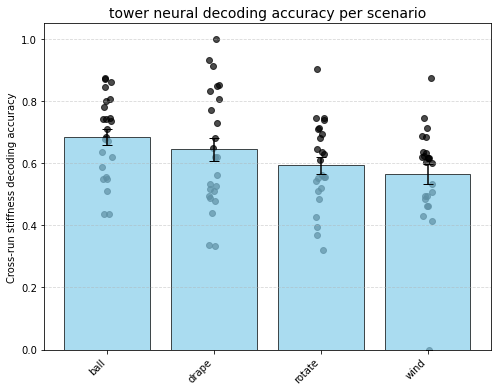

roi=tower, cor(woven, tower)=(0.652, p=0.003); cor(cnn, tower)=(-0.548, p=0.108)
Bootstrapped reliability of neural decoding accuracy = 0.7240800000000001, p=0.0474


@@@@ roi=v1 @@@@


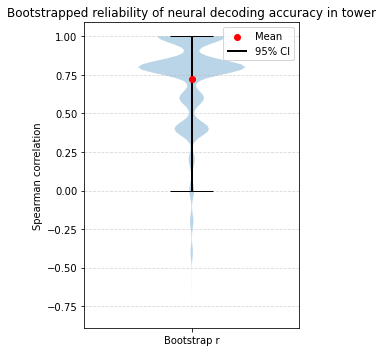

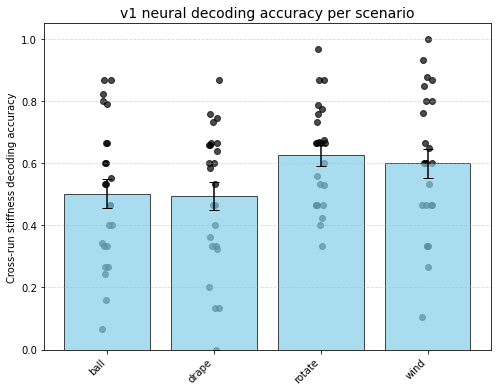

roi=v1, cor(woven, v1)=(-0.272, p=0.07); cor(cnn, v1)=(0.816, p=0.01)
Bootstrapped reliability of neural decoding accuracy = 0.74466, p=0.0336


@@@@ roi=loc @@@@


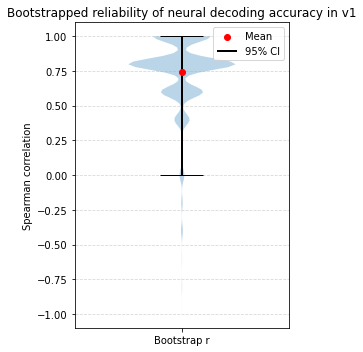

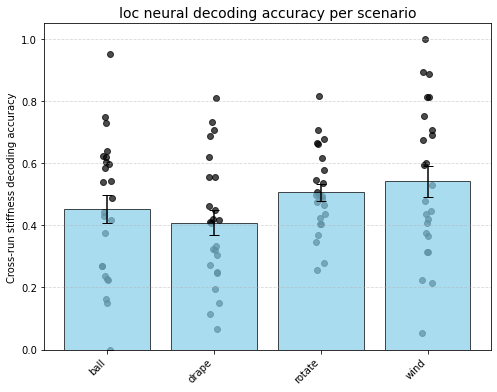

roi=loc, cor(woven, loc)=(-0.33, p=0.113); cor(cnn, loc)=(0.735, p=0.008)
Bootstrapped reliability of neural decoding accuracy = 0.7306916227766017, p=0.037


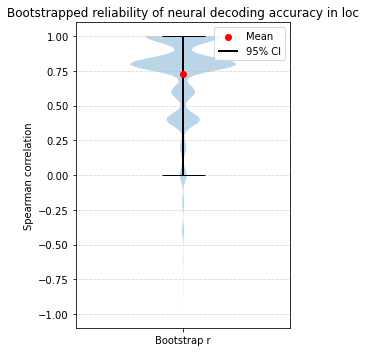

In [4]:
rois = ["tower", "v1", "loc"]

human_acc = {}
human_woven_cor = {}
human_cnn_cor = {}
best_svm = {}

for roi in rois:
    print("\n")
    print(f"@@@@ roi={roi} @@@@")
    best_split_half_r_all_subs = -1
    best_split_half_p = None
    best_all_acc_means = None
    best_bootstrap_correlation = None
    best_params = None

    # ----------------------------------------------------
    # Search best SVM setting by split-half reliability
    # ----------------------------------------------------
    for leave_scene in ["1", "2"]:
        for C in ["0.1", "1.0", "10.0", "100.0"]:
            for smooth in ["0", "1", "2"]:
        
                input_dir = opj(
                    CONFIG["output_root"],
                    "analysis",
                    "fig3",
                    f"leave-{leave_scene}-run-out",
                    f"C={C}",
                    f"smooth={smooth}",
                    roi,
                )

                all_data = []
                files = opj(input_dir, "*.json")
                files = glob.glob(files, recursive=False)

                for f in files:
                    with open(f, "r") as f_obj:
                        data = json.load(f_obj)["tower_acc_all_tmps"]

                    for key_sub in data:
                        for key_scene in data[key_sub]:
                            data[key_sub][key_scene] = np.mean(
                                data[key_sub][key_scene]
                            )

                    scene_order = CONFIG["scenes"]
                    subjects = sorted(data.keys())

                    array_2d = np.array([
                        [data[subj][scene] for scene in scene_order]
                        for subj in subjects
                    ])

                    all_data.append(array_2d)

                all_acc_means = np.mean(np.array(all_data), axis=0)
                acc_across_scene = np.mean(all_acc_means, axis=0)

                split_half_r_all_subs, p, bootstrap_correlations = bootstrap_cor(
                    all_acc_means,
                    seed=99,
                )

                if split_half_r_all_subs > best_split_half_r_all_subs:
                    best_split_half_r_all_subs = split_half_r_all_subs
                    best_split_half_p = p
                    best_bootstrap_correlation = dc(bootstrap_correlations)
                    best_all_acc_means = dc(all_acc_means)
                    best_params = {
                        "leave_scene": leave_scene,
                        "C": C,
                        "smooth": smooth,
                        "input_dir": input_dir,
                    }

    human_acc[roi] = dc(best_all_acc_means)

    best_params[roi] = {
        "split_half_r": best_split_half_r_all_subs,
        "split_half_p": best_split_half_p,
        "bootstrap_correlation": dc(best_bootstrap_correlation),
        "acc": dc(best_all_acc_means),
        "params": dc(best_params),
    }

    # ----------------------------------------------------
    # Plot neural accuracy
    # ----------------------------------------------------
    normalized_data = (
        best_all_acc_means - best_all_acc_means.min()
    ) / (
        best_all_acc_means.max() - best_all_acc_means.min()
    )

    means = normalized_data.mean(axis=0)
    sems = normalized_data.std(axis=0) / np.sqrt(normalized_data.shape[0])

    x = np.arange(normalized_data.shape[1])

    plt.figure(figsize=(8, 6))

    plt.bar(
        x,
        means,
        yerr=sems,
        capsize=5,
        color="skyblue",
        alpha=0.7,
        edgecolor="black",
        label="Mean ± SEM",
    )

    for i in range(normalized_data.shape[1]):
        plt.scatter(
            np.full(normalized_data.shape[0], i)
            + np.random.uniform(-0.05, 0.05, size=normalized_data.shape[0]),
            normalized_data[:, i],
            color="black",
            alpha=0.7,
        )

    plt.xticks(x, CONFIG["scenes"], rotation=45, ha="right")
    plt.ylabel("Cross-run stiffness decoding accuracy")
    plt.title(
        f"{roi} neural decoding accuracy per scenario",
        fontsize=14,
    )
    plt.grid(True, axis="y", linestyle="--", alpha=0.5)
    plt.show()

    # ----------------------------------------------------
    # Plot bootstrapped reliability
    # ----------------------------------------------------
    fig, ax = plot_bootstrap_violin(
        best_bootstrap_correlation,
        best_split_half_r_all_subs,
        title=f"Bootstrapped reliability of neural decoding accuracy in {roi}"
    )

    # ----------------------------------------------------
    # Correlation with models
    # ----------------------------------------------------
    nsub = best_all_acc_means.shape[0]

    cur_human_woven_cor = []
    cur_human_cnn_cor = []

    for curboot in range(10000):
        human_boot_indices = np.random.choice(nsub, nsub, replace=True)
        human_boot = best_all_acc_means[human_boot_indices, :]
        human_boot_acc_across_scenes = np.mean(human_boot, axis=0)

        cur_human_woven_cor, _ = spearmanr(
            woven_mean,
            human_boot_acc_across_scenes,
        )

        cur_human_cnn_cor, _ = spearmanr(
            cnn_mean,
            human_boot_acc_across_scenes,
        )

        cur_human_woven_cor = cur_human_woven_cor
        cur_human_cnn_cor = cur_human_cnn_cor

        human_woven_cor.setdefault(roi, []).append(cur_human_woven_cor)
        human_cnn_cor.setdefault(roi, []).append(cur_human_cnn_cor)

    cnn_cor_mean = round(np.mean(human_cnn_cor[roi]), 3)
    cnn_cor_p = round(calc_p(human_cnn_cor[roi]), 3)

    woven_cor_mean = round(np.mean(human_woven_cor[roi]), 3)
    woven_cor_p = round(calc_p(human_woven_cor[roi]), 3)
    

    print(
        f"roi={roi}, "
        f"cor(woven, {roi})=({woven_cor_mean}, p={woven_cor_p}); "
        f"cor(cnn, {roi})=({cnn_cor_mean}, p={cnn_cor_p})"
    )
    print(
        f"Bootstrapped reliability of neural decoding accuracy = {best_split_half_r_all_subs}, "
        f"p={best_split_half_p}"
    )

In [5]:
# ----------------------------------------------------
# Keep old variable names for downstream cells
# ----------------------------------------------------
human_acc_tower = dc(human_acc["tower"])
human_acc_v1 = dc(human_acc["v1"])
human_acc_loc = dc(human_acc["loc"])

human_woven_cor_tower = dc(human_woven_cor["tower"])
human_woven_cor_v1 = dc(human_woven_cor["v1"])
human_woven_cor_loc = dc(human_woven_cor["loc"])

human_cnn_cor_tower = dc(human_cnn_cor["tower"])
human_cnn_cor_v1 = dc(human_cnn_cor["v1"])
human_cnn_cor_loc = dc(human_cnn_cor["loc"])


# ----------------------------------------------------
# Bootstrap interaction
# ----------------------------------------------------
diff_tower = (
    np.mean(human_woven_cor_tower)
    - np.mean(human_cnn_cor_tower)
)

diff_v1 = (
    np.mean(human_woven_cor_v1)
    - np.mean(human_cnn_cor_v1)
)

diff = diff_tower - diff_v1

print(
    f"[physics-v1] interaction p={calc_p(diff)}, "
    f"diff_tower={diff_tower}, diff_v1={diff_v1}"
)


diff_loc = (
    np.mean(human_woven_cor_loc)
    - np.mean(human_cnn_cor_loc)
)

diff = diff_v1 - diff_loc

print(
    f"[v1-loc] interaction p={calc_p(diff)}, "
    f"diff_v1={diff_v1}, diff_loc={diff_loc}"
)

[physics-v1] interaction p=0.0, diff_tower=1.20058, diff_v1=-1.0881600000000002
[v1-loc] interaction p=0.0, diff_v1=-1.0881600000000002, diff_loc=-1.06494


# Fig. 3E

In [6]:
## 2-way ANOVA
human_v1_cor_woven = [spearmanr(human_acc_v1[i,], woven_mean) for i in range(human_acc_v1.shape[0])]
human_v1_cor_woven = [i[0] for i in human_v1_cor_woven]
human_v1_cor_cnn = [spearmanr(human_acc_v1[i,], cnn_mean) for i in range(human_acc_v1.shape[0])]
human_v1_cor_cnn = [i[0] for i in human_v1_cor_cnn]

human_phy_cor_woven = [spearmanr(human_acc_tower[i,], woven_mean) for i in range(human_acc_tower.shape[0])]
human_phy_cor_woven = [i[0] for i in human_phy_cor_woven]
human_phy_cor_cnn = [spearmanr(human_acc_tower[i,], cnn_mean) for i in range(human_acc_tower.shape[0])]
human_phy_cor_cnn = [i[0] for i in human_phy_cor_cnn]


df = pd.DataFrame({
    'v1_cnn': human_v1_cor_cnn,
    'v1_woven': human_v1_cor_woven,
    'phy_cnn': human_phy_cor_cnn,
    'phy_woven': human_phy_cor_woven
})

n_subjects = len(df)
df['subject'] = range(1, n_subjects + 1)

df_long = pd.melt(
    df,
    id_vars='subject',
    value_vars=['v1_cnn', 'v1_woven', 'phy_cnn', 'phy_woven'],
    var_name='condition',
    value_name='value'
)

df_long[['region', 'model']] = df_long['condition'].str.split('_', expand=True)

aov = pg.rm_anova(
    dv='value',
    within=['region', 'model'],
    subject='subject',
    data=df_long,
    detailed=True
)

print("##### Anova: Region [physics,v1] * Model [woven, cnn] ##### \n")
print(aov)

##### Anova: Region [physics,v1] * Model [woven, cnn] ##### 

           Source        SS  ddof1  ddof2        MS         F     p-unc  \
0          region  0.215899      1     23  0.215899  0.890422  0.355171   
1           model  0.027643      1     23  0.027643  0.091335  0.765203   
2  region * model  2.436503      1     23  2.436503  5.934739  0.023003   

   p-GG-corr       ng2  eps  
0   0.355171  0.006783  1.0  
1   0.765203  0.000874  1.0  
2   0.023003  0.071558  1.0  


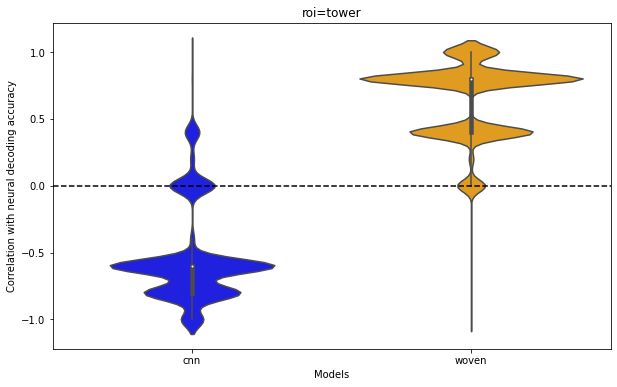

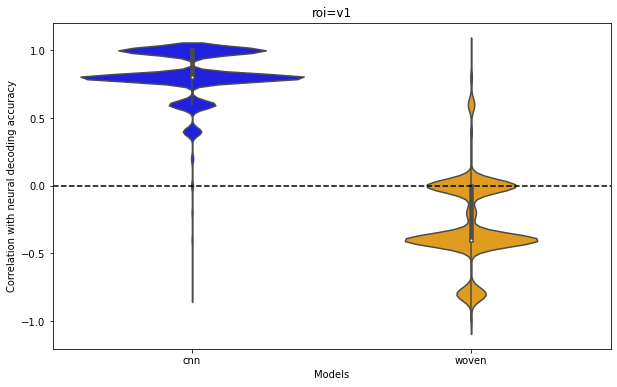

In [7]:
for roi in ['tower', 'v1']:
    cnn_data = eval(f'human_cnn_cor_{roi}')
    woven_data = eval(f'human_woven_cor_{roi}')
    
    data = np.array([cnn_data, woven_data]).T          
    data_df = pd.DataFrame(data, columns=['cnn', 'woven'])

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.violinplot(data=data_df, ax=ax, palette=['blue', 'orange'])

    # 
    cnn_mean = data_df['cnn'].mean()
    woven_mean = data_df['woven'].mean()

    ax.set_xlabel('Models')
    ax.set_ylabel('Correlation with neural decoding accuracy')
    ax.set_title(f'roi={roi}')
    ax.set_xticklabels(['cnn', 'woven'])
    ax.axhline(y=0.0, color='black', linestyle='--')

    ax.set_xlim(-0.5, 1.5)
    plt.show()


# Supplementary Fig. 6C


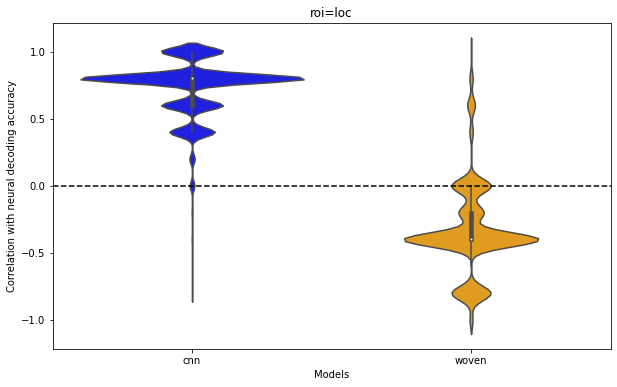

In [8]:
for roi in ['loc']:
    cnn_data = eval(f'human_cnn_cor_{roi}')
    woven_data = eval(f'human_woven_cor_{roi}')
    
    data = np.array([cnn_data, woven_data]).T          
    data_df = pd.DataFrame(data, columns=['cnn', 'woven'])

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.violinplot(data=data_df, ax=ax, palette=['blue', 'orange'])

    # 
    cnn_mean = data_df['cnn'].mean()
    woven_mean = data_df['woven'].mean()

    ax.set_xlabel('Models')
    ax.set_ylabel('Correlation with neural decoding accuracy')
    ax.set_title(f'roi={roi}')
    ax.set_xticklabels(['cnn', 'woven'])
    ax.axhline(y=0.0, color='black', linestyle='--')

    ax.set_xlim(-0.5, 1.5)
    plt.show()
